# Ajuste de isotermas de adsorción — CMS-3K

Ajuste de isotermas de adsorción pura sobre el material **CMS-3K** para las especies
CO2, CO, N2, O2, H2, H2S y CH4, medidas a tres temperaturas (293, 308 y 323 K).

## Módulos utilizados

| Módulo | Función principal | Responsabilidad |
|---|---|---|
| `src.utils.isotherm_models` | `MODEL_REGISTRY` | Modelos de isoterma pura (Langmuir, DSL, Sips...) |
| `src.utils.isotherm_fitting` | `fit_multi_T` | Ajuste multi-temperatura + estimación de dH |
| `src.utils.mixture_isotherm` | `iast`, `rast` | Isoterma de mezcla multicomponente |

## Unidades

Los datos del Excel están en **kPa**. Se convierten a **bar** al cargarlos (`P_bar = P_kPa / 100`).
Todos los modelos ajustados operan internamente en **bar**, consistente con el modelo PSA.

## Flujo

1. Carga y conversión de datos (kPa → bar)
2. Ajuste automático multi-temperatura por especie
3. Tabla resumen: modelo, parámetros, MSE, dH
4. Visualización: datos vs. ajuste (formato 7 + 2 subplots)
5. Construcción del `iso_fn` compuesto para `build_adsorbent_config`
6. Benchmark de métodos de mezcla: naive vs. IAST vs. RAST

In [1]:
import os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.utils.isotherm_models  import MODEL_REGISTRY, arrh
from src.utils.isotherm_fitting import fit_multi_T
from src.utils.mixture_isotherm import iast, rast

DATA_PATH = os.path.join(os.getcwd(), "data", "CMS-3K.xlsx")
print("Imports OK")
print("Modelos disponibles:", list(MODEL_REGISTRY.keys()))
print("Datos:", os.path.basename(DATA_PATH), "| existe:", os.path.isfile(DATA_PATH))

Imports OK
Modelos disponibles: ['Langmuir', 'Freundlich', 'Quadratic', 'Sips', 'Dual-site Langmuir']
Datos: CMS-3K.xlsx | existe: True


## 1. Carga y conversión de datos experimentales

In [2]:
SPECIES = ["CO2", "CO", "N2", "O2", "H2", "H2S", "CH4"]
T_LIST  = [293.0, 308.0, 323.0]   # [K]
KPA2BAR = 1.0 / 100.0             # kPa → bar

data = {}
for sp in SPECIES:
    df = pd.read_excel(DATA_PATH, sheet_name=sp)
    data[sp] = {}
    for T in T_LIST:
        T_int = int(T)
        P_kpa = df[f"P(kPa)-{T_int}(K)"].dropna().values
        q_val = df[f"q(mol/kg)-{T_int}(K)"].dropna().values
        data[sp][T] = (P_kpa * KPA2BAR, q_val)   # P en bar, q en mol/kg

print(f"Datos cargados: {len(SPECIES)} especies × {len(T_LIST)} temperaturas")
sp0, T0 = SPECIES[0], T_LIST[0]
P0, q0 = data[sp0][T0]
print(f"  {sp0} @ {T0} K → P [bar]: {P0[:4].round(3)} ...")
print(f"  {sp0} @ {T0} K → q [mol/kg]: {q0[:4].round(3)} ...")

Datos cargados: 7 especies × 3 temperaturas
  CO2 @ 293.0 K → P [bar]: [0.25 0.5  1.   2.  ] ...
  CO2 @ 293.0 K → q [mol/kg]: [0.65 1.1  1.6  2.2 ] ...


## 2. Ajuste automático multi-temperatura

`fit_multi_T` selecciona el modelo de menor MSE y estima **dH** [J/mol] por desplazamiento de Arrhenius.
El resultado es un callable `iso_fn(P_bar, T_K) → q [mol/kg]`.

In [3]:
fit_results = {}

for sp in SPECIES:
    P_list = [data[sp][T][0] for T in T_LIST]
    q_list = [data[sp][T][1] for T in T_LIST]
    t0 = time.time()
    iso_fn, par, name, mse, dH, T_ref = fit_multi_T(
        P_list=P_list, q_list=q_list, T_list=T_LIST,
        i_ref=0, mse_tol=1e-5,
    )
    elapsed = time.time() - t0
    fit_results[sp] = dict(iso_fn=iso_fn, par=par, name=name,
                           mse=mse, dH=dH, T_ref=T_ref)
    print(f"  {sp:4s} | {name:22s} | MSE={mse:.3e} | dH={dH/1e3:6.1f} kJ/mol | {elapsed:.1f} s")

print("\nAjuste completado.")

  CO2  | Dual-site Langmuir     | MSE=1.632e-04 | dH=  14.4 kJ/mol | 4.4 s
  CO   | Langmuir               | MSE=6.099e-10 | dH=  -0.0 kJ/mol | 0.4 s
  N2   | Langmuir               | MSE=6.099e-10 | dH=  -0.0 kJ/mol | 0.5 s
  O2   | Langmuir               | MSE=6.099e-10 | dH=  -0.0 kJ/mol | 0.4 s
  H2   | Langmuir               | MSE=6.099e-10 | dH=  -0.0 kJ/mol | 0.4 s
  H2S  | Langmuir               | MSE=6.099e-10 | dH=  -0.0 kJ/mol | 0.5 s
  CH4  | Quadratic              | MSE=7.075e-05 | dH=  20.9 kJ/mol | 2.8 s

Ajuste completado.


## 3. Tabla resumen de ajustes

In [4]:
rows = []
for sp in SPECIES:
    r = fit_results[sp]
    rows.append({
        "Especie":          sp,
        "Modelo":           r["name"],
        "n_par":            len(r["par"]),
        "Parámetros [bar]": str(r["par"].round(4)),
        "MSE":              r["mse"],
        "dH [kJ/mol]":      r["dH"] / 1e3,
        "T_ref [K]":        r["T_ref"],
    })

pd.set_option("display.float_format", "{:.4g}".format)
pd.DataFrame(rows).set_index("Especie")

,Modelo,n_par,Parámetros [bar],MSE,dH [kJ/mol],T_ref [K]
Especie,,,,,,
CO2,Dual-site Langmuir,4,[2.2007 1.3269 1.5412 0.3077],0.0001632,14.43,293
CO,Langmuir,2,[0.0035 0.8946],6.099e-10,-0.0006125,293
N2,Langmuir,2,[0.0035 0.8946],6.099e-10,-0.0006125,293
O2,Langmuir,2,[0.0035 0.8946],6.099e-10,-0.0006125,293
H2,Langmuir,2,[0.0035 0.8946],6.099e-10,-0.0006125,293
H2S,Langmuir,2,[0.0035 0.8946],6.099e-10,-0.0006125,293
CH4,Quadratic,3,[2.5867 0.4066 0.0543],7.075e-05,20.86,293


## 4. Visualización: datos vs. ajuste

**Figura 1** — las 7 especies en subplots independientes.  
**Figura 2** — detalle de la primera especie (CO2) y la última (CH4).

Línea continua = datos experimentales. Puntos = predicción del modelo ajustado.

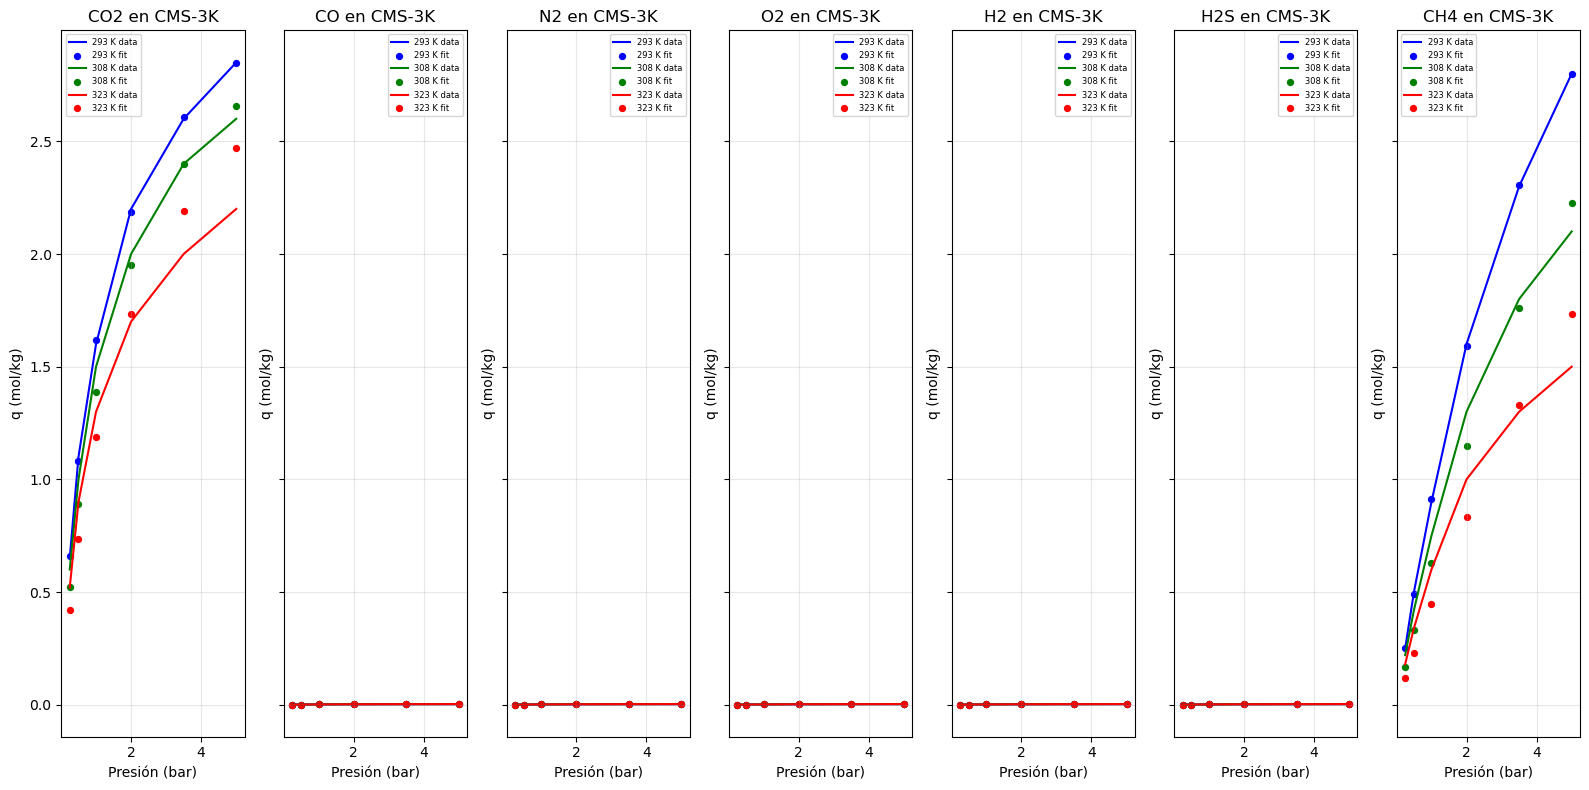

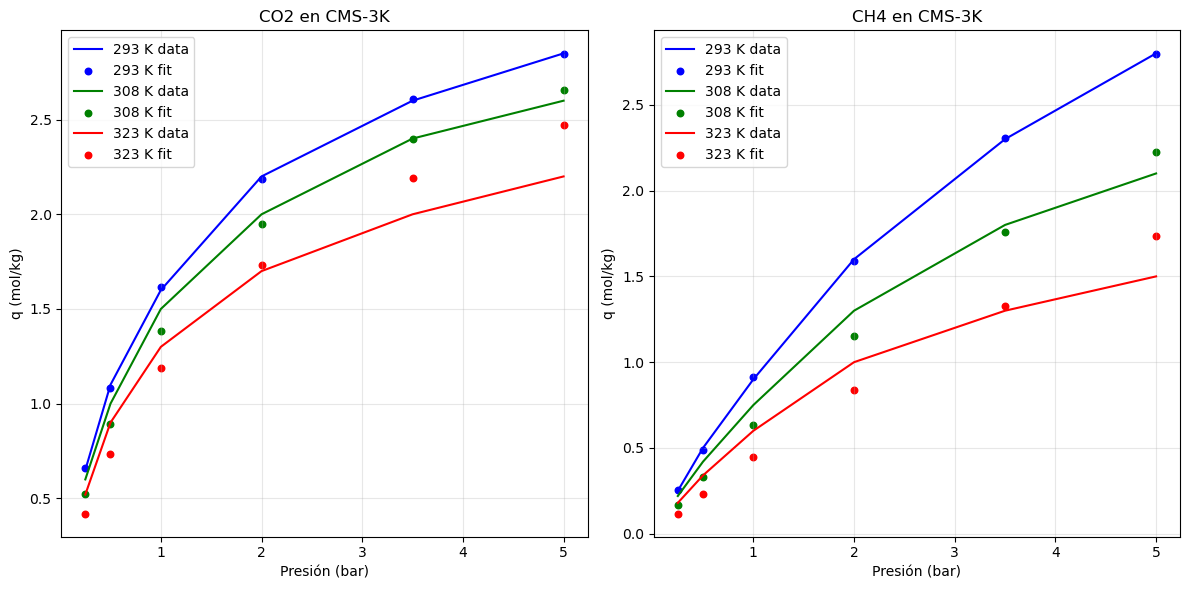

In [5]:
COLORS = ["b", "g", "r"]   # azul / verde / rojo por temperatura

# ── Figura 1: todos los 7 ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(SPECIES), figsize=(16, 8), sharey=True)

for ax, sp in zip(axes, SPECIES):
    iso_fn = fit_results[sp]["iso_fn"]
    for j, T in enumerate(T_LIST):
        P_exp, q_exp = data[sp][T]
        q_fit = np.array([iso_fn(float(p), T) for p in P_exp])
        ax.plot(P_exp,  q_exp, linestyle="-",  color=COLORS[j], label=f"{int(T)} K data")
        ax.scatter(P_exp, q_fit, marker="o",   color=COLORS[j], s=18,  label=f"{int(T)} K fit")
    ax.set_title(f"{sp} en CMS-3K")
    ax.set_xlabel("Presión (bar)")
    ax.set_ylabel("q (mol/kg)")
    ax.legend(fontsize=6)
    ax.grid(alpha=0.3)

plt.subplots_adjust(wspace=0.0, left=0.06, right=0.98)
plt.tight_layout()
plt.show()

# ── Figura 2: detalle primera y última especie ─────────────────────────────
selected = [SPECIES[0], SPECIES[-1]]
fig2, axes2 = plt.subplots(1, 2, figsize=(12, 6), sharey=False)

for ax, sp in zip(axes2, selected):
    iso_fn = fit_results[sp]["iso_fn"]
    for j, T in enumerate(T_LIST):
        P_exp, q_exp = data[sp][T]
        q_fit = np.array([iso_fn(float(p), T) for p in P_exp])
        ax.plot(P_exp,  q_exp, linestyle="-",  color=COLORS[j], label=f"{int(T)} K data")
        ax.scatter(P_exp, q_fit, marker="o",   color=COLORS[j], s=22,  label=f"{int(T)} K fit")
    ax.set_title(f"{sp} en CMS-3K")
    ax.set_xlabel("Presión (bar)")
    ax.set_ylabel("q (mol/kg)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.subplots_adjust(wspace=0.3, left=0.08, right=0.97)
plt.tight_layout()
plt.show()

## 5. Construcción del `iso_fn` compuesto para el modelo PSA

`build_adsorbent_config` espera un callable con la firma:

```python
iso_fn(P_part_list, Ts) → ndarray (nc, N)
```

donde `P_part_list` es una lista de `nc` arrays `(N,)` en **bar** y `Ts` es `(N,)` en **K**.

La mezcla de trabajo es **CO2 / N2 / CH4** (3 componentes).

In [6]:
MIX_SPECIES  = ["CO2", "N2", "CH4"]
iso_fns_pure = [fit_results[sp]["iso_fn"] for sp in MIX_SPECIES]

def iso_fn_psa(P_part_list, Ts):
    """
    Isoterma de equilibrio para uso en build_adsorbent_config.
    P_part_list : list of nc arrays (N,) [bar]
    Ts          : ndarray (N,) [K]
    Returns     : ndarray (nc, N) [mol/kg]
    """
    Ts_arr = np.asarray(Ts, dtype=float)
    N  = len(Ts_arr)
    nc = len(iso_fns_pure)
    q_eq = np.zeros((nc, N), dtype=float)
    for i, (iso, P_i) in enumerate(zip(iso_fns_pure, P_part_list)):
        P_arr = np.asarray(P_i, dtype=float)
        for n in range(N):
            q_eq[i, n] = iso(P_arr[n], Ts_arr[n])
    return q_eq

# Verificacion: 5 nodos, presiones parciales tipicas de una mezcla biogas
N_test  = 5
Ts_t    = np.full(N_test, 308.0)            # K
P_CO2_t = np.linspace(0.10, 0.40, N_test)  # bar
P_N2_t  = np.linspace(0.05, 0.15, N_test)  # bar
P_CH4_t = np.linspace(0.45, 0.85, N_test)  # bar

q_check = iso_fn_psa([P_CO2_t, P_N2_t, P_CH4_t], Ts_t)

print(f"q_eq shape: {q_check.shape}   (esperado: ({len(MIX_SPECIES)}, {N_test}))")
pd.DataFrame(
    q_check.T,
    columns=MIX_SPECIES,
    index=[f"nodo_{i}" for i in range(N_test)],
)

q_eq shape: (3, 5)   (esperado: (3, 5))


,CO2,N2,CH4
nodo_0,0.2338,0.0001478,0.2991
nodo_1,0.386,0.0002171,0.3622
nodo_2,0.5221,0.0002835,0.424
nodo_3,0.6449,0.0003473,0.4847
nodo_4,0.7564,0.0004085,0.5441


## 6. Benchmark de métodos de mezcla: naive vs. IAST vs. RAST

Compara los tres métodos para la mezcla ternaria **CO2 / N2 / CH4** a presión total 1 bar
y temperatura 308 K.

Estrategia del barrido: se fija `y_CH4 = 0.10` y se varía `y_CO2` de 0.05 a 0.85,
con `y_N2 = 1 − y_CO2 − y_CH4`. Esto simula una mezcla tipo biogás con metano de fondo.

| Método | Descripción |
|---|---|
| **Naive** | Isotermas independientes: `q_i = iso_i(y_i · P_tot)`. Sin interacción entre componentes. |
| **IAST** | Ideal Adsorbed Solution Theory. Equilibrio de fases adsorbidas ideal (γ_i = 1). |
| **RAST** | Real Adsorbed Solution Theory con modelo de Wilson. No-idealidad en la fase adsorbida. |

In [7]:
T_BM  = 308.0   # K
P_TOT = 1.0     # bar
Y_CH4 = 0.10    # fraccion molar CH4 fija

# y_CO2 variable; y_N2 = 1 - y_CO2 - y_CH4
Y_CO2 = np.linspace(0.05, 0.85, 15)

# Matriz de Wilson 3x3 (punto de partida cuasi-ideal con interaccion moderada)
Lambda_rast = np.array([[1.0, 0.8, 0.7],
                         [0.8, 1.0, 0.9],
                         [0.7, 0.9, 1.0]])
C_rast = 0.5

records = []
times   = {"naive": [], "iast": [], "rast": []}

for y_CO2 in Y_CO2:
    y_N2 = 1.0 - y_CO2 - Y_CH4
    if y_N2 < 0.0:
        continue
    P_i = np.array([y_CO2 * P_TOT, y_N2 * P_TOT, Y_CH4 * P_TOT])

    # --- naive ---
    t0 = time.perf_counter()
    q_naive = np.array([iso_fns_pure[i](P_i[i], T_BM) for i in range(3)])
    times["naive"].append(time.perf_counter() - t0)

    # --- IAST ---
    t0 = time.perf_counter()
    q_iast = iast(iso_fns_pure, P_i, T_BM)
    times["iast"].append(time.perf_counter() - t0)

    # --- RAST ---
    t0 = time.perf_counter()
    q_rast = rast(iso_fns_pure, P_i, T_BM, Lambda_rast, C_rast)
    times["rast"].append(time.perf_counter() - t0)

    row = {"y_CO2": y_CO2, "y_N2": y_N2, "y_CH4": Y_CH4}
    for i, sp in enumerate(MIX_SPECIES):
        row[f"q_{sp} naive"] = q_naive[i]
        row[f"q_{sp} IAST"]  = q_iast[i]
        row[f"q_{sp} RAST"]  = q_rast[i]
    for ref_sp, ref_i in [("N2", 1), ("CH4", 2)]:
        for method, q_arr in [("naive", q_naive), ("IAST", q_iast), ("RAST", q_rast)]:
            row[f"sel CO2/{ref_sp} {method}"] = q_arr[0] / max(q_arr[ref_i], 1e-10)
    records.append(row)

df_bm = pd.DataFrame(records)
pd.set_option("display.float_format", "{:.4f}".format)

print("Tiempos medios por llamada:")
for m, t in times.items():
    print(f"  {m:6s}: {np.mean(t)*1e3:.2f} ms")

print()
cols_q = ["y_CO2", "y_N2", "y_CH4"]
for sp in MIX_SPECIES:
    cols_q += [f"q_{sp} naive", f"q_{sp} IAST", f"q_{sp} RAST"]
df_bm[cols_q]

Tiempos medios por llamada:
  naive : 0.08 ms
  iast  : 4374.66 ms
  rast  : 1434.26 ms



,y_CO2,y_N2,y_CH4,q_CO2 naive,q_CO2 IAST,q_CO2 RAST,q_N2 naive,q_N2 IAST,q_N2 RAST,q_CH4 naive,q_CH4 IAST,q_CH4 RAST
0,0.0500,0.8500,0.1000,0.1218,-0.0000,-0.0000,0.0015,0.0000,0.0000,0.0687,-0.0000,-0.0000
1,0.1071,0.7929,0.1000,0.2490,-0.0000,-0.0000,0.0014,0.0000,0.0000,0.0687,-0.0000,-0.0000
2,0.1643,0.7357,0.1000,0.3653,-0.0000,-0.0000,0.0014,0.0000,0.0000,0.0687,-0.0000,-0.0000
3,0.2214,0.6786,0.1000,0.4720,-0.0000,-0.0000,0.0013,0.0000,0.0000,0.0687,-0.0000,-0.0000
4,0.2786,0.6214,0.1000,0.5704,-0.0000,-0.0000,0.0012,0.0000,0.0000,0.0687,-0.0000,-0.0000
5,0.3357,0.5643,0.1000,0.6615,-0.0000,-0.0000,0.0012,0.0000,0.0000,0.0687,-0.0000,-0.0000
6,0.3929,0.5071,0.1000,0.7462,-0.0000,-0.0000,0.0011,0.0000,0.0000,0.0687,-0.0000,-0.0000
7,0.4500,0.4500,0.1000,0.8252,-0.0000,-0.0000,0.0010,0.0000,0.0000,0.0687,-0.0000,-0.0000
8,0.5071,0.3929,0.1000,0.8991,-0.0000,-0.0000,0.0009,0.0000,0.0000,0.0687,-0.0000,-0.0000
9,0.5643,0.3357,0.1000,0.9684,-0.0000,-0.0000,0.0008,0.0000,0.0000,0.0687,-0.0000,-0.0000


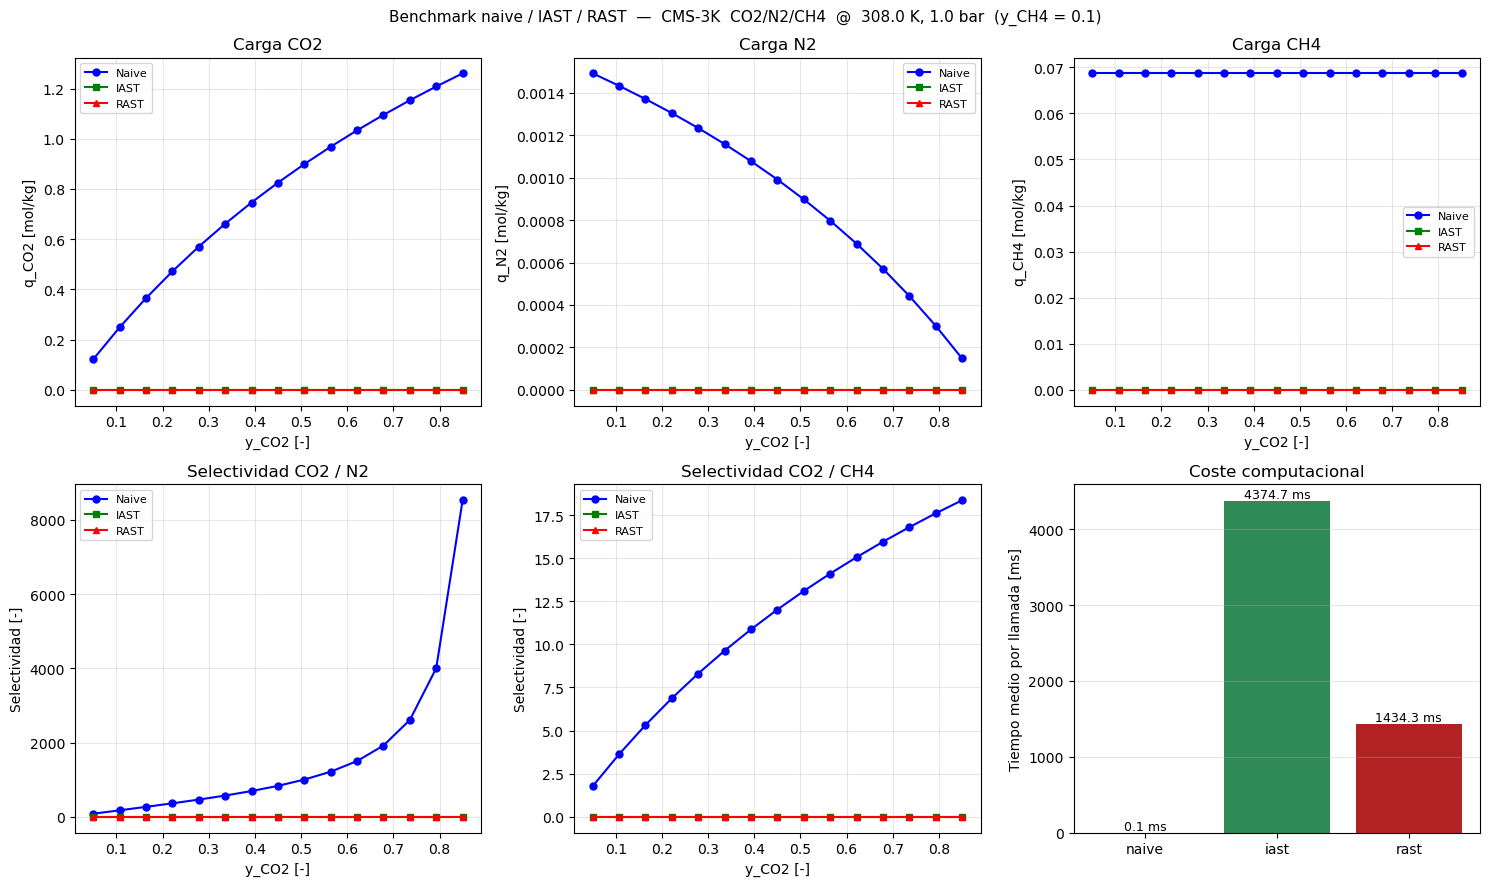

,t_medio [ms],t_total [ms],n_llamadas
Metodo,,,
naive,0.0846,1.2693,15
iast,4374.6587,65619.8801,15
rast,1434.2632,21513.9480,15


In [8]:
x_axis  = df_bm["y_CO2"]
x_label = "y_CO2 [-]"

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# ── Fila 1: carga por especie ──────────────────────────────────────────────
for col_idx, sp in enumerate(MIX_SPECIES):
    ax = axes[0, col_idx]
    ax.plot(x_axis, df_bm[f"q_{sp} naive"], "b-o", ms=5, label="Naive")
    ax.plot(x_axis, df_bm[f"q_{sp} IAST"],  "g-s", ms=5, label="IAST")
    ax.plot(x_axis, df_bm[f"q_{sp} RAST"],  "r-^", ms=5, label="RAST")
    ax.set_xlabel(x_label)
    ax.set_ylabel(f"q_{sp} [mol/kg]")
    ax.set_title(f"Carga {sp}")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# ── Fila 2: selectividades y tiempos ──────────────────────────────────────
ax = axes[1, 0]
ax.plot(x_axis, df_bm["sel CO2/N2 naive"], "b-o", ms=5, label="Naive")
ax.plot(x_axis, df_bm["sel CO2/N2 IAST"],  "g-s", ms=5, label="IAST")
ax.plot(x_axis, df_bm["sel CO2/N2 RAST"],  "r-^", ms=5, label="RAST")
ax.set_xlabel(x_label)
ax.set_ylabel("Selectividad [-]")
ax.set_title("Selectividad CO2 / N2")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(x_axis, df_bm["sel CO2/CH4 naive"], "b-o", ms=5, label="Naive")
ax.plot(x_axis, df_bm["sel CO2/CH4 IAST"],  "g-s", ms=5, label="IAST")
ax.plot(x_axis, df_bm["sel CO2/CH4 RAST"],  "r-^", ms=5, label="RAST")
ax.set_xlabel(x_label)
ax.set_ylabel("Selectividad [-]")
ax.set_title("Selectividad CO2 / CH4")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── Tiempos de calculo ────────────────────────────────────────────────────
ax = axes[1, 2]
metodos     = list(times.keys())
t_medios_ms = [np.mean(t) * 1e3 for t in times.values()]
bars = ax.bar(metodos, t_medios_ms, color=["steelblue", "seagreen", "firebrick"])
for bar, val in zip(bars, t_medios_ms):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.1f} ms", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Tiempo medio por llamada [ms]")
ax.set_title("Coste computacional")
ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    f"Benchmark naive / IAST / RAST  —  CMS-3K  CO2/N2/CH4"
    f"  @  {T_BM} K, {P_TOT} bar  (y_CH4 = {Y_CH4})",
    fontsize=11,
)
plt.tight_layout()
plt.show()

# ── tabla resumen tiempos ─────────────────────────────────────────────────
df_times = pd.DataFrame({
    "Metodo":       metodos,
    "t_medio [ms]": [np.mean(t)*1e3 for t in times.values()],
    "t_total [ms]": [np.sum(t)*1e3  for t in times.values()],
    "n_llamadas":   [len(t)          for t in times.values()],
}).set_index("Metodo")
display(df_times)